In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# config
SEASON = 2006
DATA_DIR = "pbp"

PLAYER_NAME = "K. Bryant"
PLAYER_ID = 977

SHOT_TYPES = ["Made Shot", "Missed Shot"]
MIN_SHOTS_PER_GAME = 10

In [3]:
# load & prep data
def get_data_path(season, data_dir="pbp"):
    return f"{data_dir}/pbp{season}.csv"


def load_and_prepare_player_data(
    season,
    data_dir="pbp",
    player_name=None,
    player_id=None,
    shot_types=("Made Shot", "Missed Shot"),
    min_shots_per_game=10
):
    data_path = get_data_path(season, data_dir)
    df = pd.read_csv(data_path).copy()

    # clean text columns if they exist
    for col in ["player", "type", "result", "clock"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # filter to player
    if player_id is not None and "playerid" in df.columns:
        df = df[df["playerid"] == player_id]
    elif player_name is not None and "player" in df.columns:
        df = df[df["player"] == player_name]

    # filter to shot attempts
    df = df[df["type"].isin(shot_types)].copy()

    # sort in shot order within each game
    sort_cols = [c for c in ["gameid", "period", "time"] if c in df.columns]
    if "clock" in df.columns:
        df = df.sort_values(["gameid", "period", "clock"], ascending=[True, True, False])
    elif len(sort_cols) > 0:
        df = df.sort_values(sort_cols)

    # binary outcome
    df["made"] = (df["result"] == "Made").astype(int)

    # keep games with enough shots
    shot_counts = df.groupby("gameid").size()
    valid_games = shot_counts[shot_counts >= min_shots_per_game].index
    df = df[df["gameid"].isin(valid_games)].copy()

    # reset index
    df = df.reset_index(drop=True)

    return df

In [4]:
# build logistic AR features
def build_make_streak(series):
    streak = []
    count = 0
    for x in series:
        streak.append(count)
        if x == 1:
            count += 1
        else:
            count = 0
    return streak


def build_miss_streak(series):
    streak = []
    count = 0
    for x in series:
        streak.append(count)
        if x == 0:
            count += 1
        else:
            count = 0
    return streak


def build_logistic_ar_dataframe(df, num_lags=3):
    out = df.copy()

    # lag features within each game
    for lag in range(1, num_lags + 1):
        out[f"lag_{lag}"] = out.groupby("gameid")["made"].shift(lag)

    # rolling hit rate of previous 5 shots within each game
    out["hit_rate_5"] = (
        out.groupby("gameid")["made"]
        .transform(lambda s: s.shift(1).rolling(5, min_periods=5).mean())
    )

    # streak features
    out["make_streak"] = out.groupby("gameid")["made"].transform(build_make_streak)
    out["miss_streak"] = out.groupby("gameid")["made"].transform(build_miss_streak)

    # optional shot number within game
    out["shot_num"] = out.groupby("gameid").cumcount()

    # keep rows with full lag history + hit rate
    required_cols = [f"lag_{i}" for i in range(1, num_lags + 1)] + ["hit_rate_5"]
    out = out.dropna(subset=required_cols).copy()

    # convert to numeric
    for col in required_cols:
        out[col] = out[col].astype(float)

    out["make_streak"] = out["make_streak"].astype(float)
    out["miss_streak"] = out["miss_streak"].astype(float)

    return out.reset_index(drop=True)

In [5]:
# load df
df = load_and_prepare_player_data(
    season=SEASON,
    data_dir=DATA_DIR,
    player_name=PLAYER_NAME,
    player_id=PLAYER_ID,
    shot_types=SHOT_TYPES,
    min_shots_per_game=MIN_SHOTS_PER_GAME
)


print(df.shape)
df.head()

(2318, 17)


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season,made
0,20500016,1,PT10M43.00S,0.0,0.0,LAL,977,K. Bryant,Missed Shot,Driving Layup Shot,Missed,0,0,0,MISS Bryant Driving Layup,2006,0
1,20500016,1,PT09M56.00S,6.0,5.0,LAL,977,K. Bryant,Made Shot,Jump Shot,Made,79,199,21,Bryant 21' Jump Shot (2 PTS) (Parker 1 AST),2006,1
2,20500016,1,PT08M19.00S,8.0,10.0,LAL,977,K. Bryant,Made Shot,Turnaround Jump Shot,Made,-104,76,13,Bryant 13' Turnaround Jump Shot (4 PTS),2006,1
3,20500016,1,PT07M32.00S,10.0,12.0,LAL,977,K. Bryant,Made Shot,Jump Shot,Made,151,61,16,Bryant 16' Jump Shot (6 PTS) (George 1 AST),2006,1
4,20500016,1,PT07M02.00S,12.0,14.0,LAL,977,K. Bryant,Made Shot,Reverse Layup Shot,Made,0,0,0,Bryant Reverse Layup (8 PTS) (Parker 2 AST),2006,1


<Figure size 800x500 with 0 Axes>

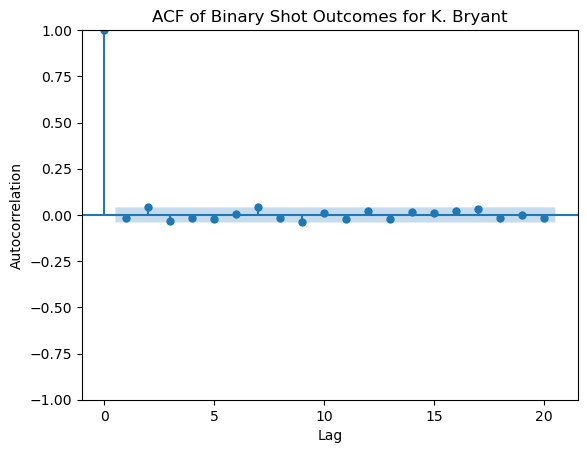

<Figure size 800x500 with 0 Axes>

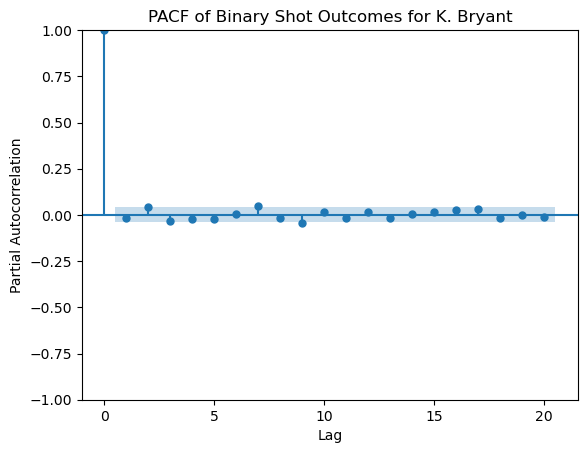

In [6]:
made_series = df["made"].astype(float)

plt.figure(figsize=(8, 5))
plot_acf(made_series, lags=20)
plt.title(f"ACF of Binary Shot Outcomes for {PLAYER_NAME}")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

plt.figure(figsize=(8, 5))
plot_pacf(made_series, lags=20, method="ywm")
plt.title(f"PACF of Binary Shot Outcomes for {PLAYER_NAME}")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

In [7]:
# model df
model_df = build_logistic_ar_dataframe(df, num_lags=3)

print(model_df.shape)
model_df.head()

(1883, 24)


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,...,desc,season,made,lag_1,lag_2,lag_3,hit_rate_5,make_streak,miss_streak,shot_num
0,20500016,1,PT06M10.00S,0.0,0.0,LAL,977,K. Bryant,Missed Shot,Jump Shot,...,MISS Bryant 23' Jump Shot,2006,0,1.0,1.0,1.0,0.8,4.0,0.0,5
1,20500016,1,PT03M50.00S,21.0,23.0,LAL,977,K. Bryant,Made Shot,Reverse Layup Shot,...,Bryant Reverse Layup (10 PTS) (George 2 AST),2006,1,0.0,1.0,1.0,0.8,0.0,1.0,6
2,20500016,2,PT07M43.00S,40.0,38.0,LAL,977,K. Bryant,Made Shot,Layup Shot,...,Bryant Layup (12 PTS) (Parker 5 AST),2006,1,1.0,0.0,1.0,0.8,1.0,0.0,7
3,20500016,2,PT07M01.00S,0.0,0.0,LAL,977,K. Bryant,Missed Shot,Jump Shot,...,MISS Bryant 16' Jump Shot,2006,0,1.0,1.0,0.0,0.8,2.0,0.0,8
4,20500016,2,PT06M46.00S,42.0,40.0,LAL,977,K. Bryant,Made Shot,Reverse Layup Shot,...,Bryant Reverse Layup (14 PTS),2006,1,0.0,1.0,1.0,0.6,0.0,1.0,9


In [8]:
feature_cols = ["lag_1", "lag_2", "lag_3", "hit_rate_5", "make_streak"]
target_col = "made"

In [9]:
game_ids = model_df["gameid"].unique()
split_idx = int(0.8 * len(game_ids))

train_games = game_ids[:split_idx]
test_games = game_ids[split_idx:]

train_df = model_df[model_df["gameid"].isin(train_games)].copy()
test_df = model_df[model_df["gameid"].isin(test_games)].copy()

print("Train games:", len(train_games))
print("Test games:", len(test_games))
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train games: 69
Test games: 18
Train rows: 1517
Test rows: 366


In [10]:
# standardize cont features using training data only
continuous_cols = ["hit_rate_5", "make_streak"]

means = {}
stds = {}

for col in continuous_cols:
    means[col] = train_df[col].mean()
    stds[col] = train_df[col].std()
    if stds[col] == 0:
        stds[col] = 1.0

    train_df[col] = (train_df[col] - means[col]) / stds[col]
    test_df[col] = (test_df[col] - means[col]) / stds[col]

In [11]:
# build X and y
X_train = train_df[feature_cols].values.astype(float)
y_train = train_df[target_col].values.reshape(-1, 1).astype(float)

X_test = test_df[feature_cols].values.astype(float)
y_test = test_df[target_col].values.reshape(-1, 1).astype(float)

In [12]:
# add intercept manually
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

In [13]:
# handwritten log regression
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def compute_loss(X, y, w):
    p = sigmoid(X @ w)
    eps = 1e-8
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))


def train_logistic_regression(X, y, lr=0.05, epochs=3000):
    n, d = X.shape
    w = np.zeros((d, 1))
    losses = []

    for epoch in range(epochs):
        z = X @ w
        p_hat = sigmoid(z)

        gradient = (X.T @ (p_hat - y)) / n
        w -= lr * gradient

        loss = compute_loss(X, y, w)
        losses.append(loss)

        if epoch % 300 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return w, losses

In [14]:
# train handwritten model
w, losses = train_logistic_regression(X_train, y_train, lr=0.05, epochs=3000)
print("Learned weights:")
print(w.flatten())

Epoch 0, Loss: 0.6929
Epoch 300, Loss: 0.6839
Epoch 600, Loss: 0.6834
Epoch 900, Loss: 0.6832
Epoch 1200, Loss: 0.6832
Epoch 1500, Loss: 0.6832
Epoch 1800, Loss: 0.6832
Epoch 2100, Loss: 0.6832
Epoch 2400, Loss: 0.6832
Epoch 2700, Loss: 0.6832
Learned weights:
[-0.1984202  -0.23784491  0.20587729 -0.04571864 -0.10391148  0.15119732]


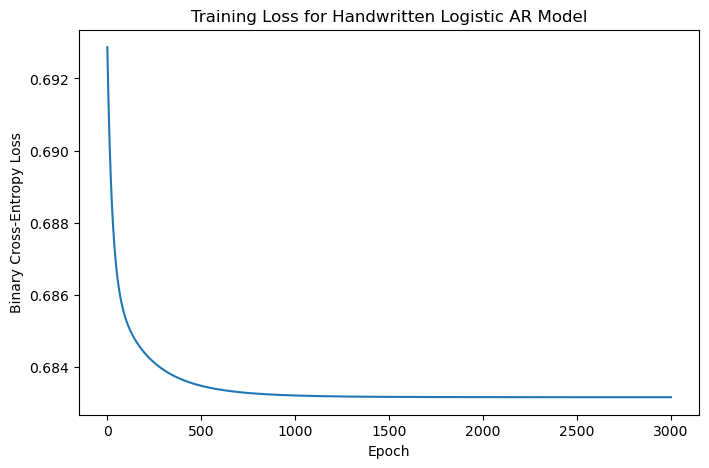

In [15]:
# plot training loss
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title("Training Loss for Handwritten Logistic AR Model")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

In [16]:
# one-step pred on test set
y_test_prob = sigmoid(X_test @ w).flatten()
y_test_pred = (y_test_prob >= 0.5).astype(int)

acc = accuracy_score(y_test.flatten(), y_test_pred)
auc = roc_auc_score(y_test.flatten(), y_test_prob)

print(f"Test Accuracy: {acc:.3f}")
print(f"Test ROC-AUC:  {auc:.3f}")

Test Accuracy: 0.519
Test ROC-AUC:  0.488


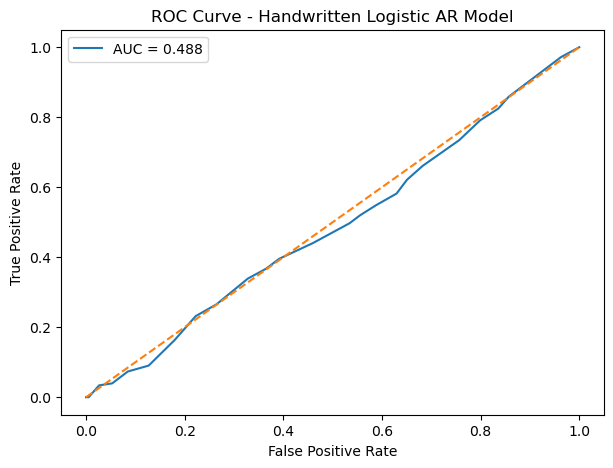

In [17]:
# roc curve
fpr, tpr, thresholds = roc_curve(y_test.flatten(), y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Handwritten Logistic AR Model")
plt.legend()
plt.show()

In [18]:
# manual sequential AR prediction by game
lag_cols = ["lag_1", "lag_2", "lag_3"]

seq_probs = []
seq_preds = []
seq_actuals = []
seq_gameids = []
seq_shotnums = []

for gameid, game_df in test_df.groupby("gameid"):
    game_df = game_df.reset_index(drop=True)

    # initialize state from the first available row in the game
    lag_state = game_df.loc[0, lag_cols].values.astype(float)

    for i in range(len(game_df)):
        row = game_df.loc[i]

        # continuous features use actual known game context
        hit_rate_5 = row["hit_rate_5"]
        make_streak = row["make_streak"]

        x_vec = np.array([1, lag_state[0], lag_state[1], lag_state[2], hit_rate_5, make_streak], dtype=float).reshape(1, -1)

        prob = sigmoid(x_vec @ w)[0, 0]
        pred = int(prob >= 0.5)
        actual = int(row["made"])

        seq_probs.append(prob)
        seq_preds.append(pred)
        seq_actuals.append(actual)
        seq_gameids.append(gameid)
        seq_shotnums.append(row["shot_num"])

        # update lag state using predicted value
        lag_state = np.array([pred, lag_state[0], lag_state[1]], dtype=float)

In [19]:
# sequential prediction eval

seq_acc = accuracy_score(seq_actuals, seq_preds)
seq_auc = roc_auc_score(seq_actuals, seq_probs)

print(f"Sequential Test Accuracy: {seq_acc:.3f}")
print(f"Sequential Test ROC-AUC:  {seq_auc:.3f}")

Sequential Test Accuracy: 0.519
Sequential Test ROC-AUC:  0.545


In [20]:
# in df
seq_results = pd.DataFrame({
    "gameid": seq_gameids,
    "shot_num": seq_shotnums,
    "actual": seq_actuals,
    "pred": seq_preds,
    "pred_prob": seq_probs
})

seq_results.head()

,gameid,shot_num,actual,pred,pred_prob
0,20501042,5,0,0,0.471630
1,20501042,6,1,0,0.420802
2,20501042,7,1,0,0.438600
3,20501042,8,1,0,0.468597
4,20501042,9,1,0,0.498823


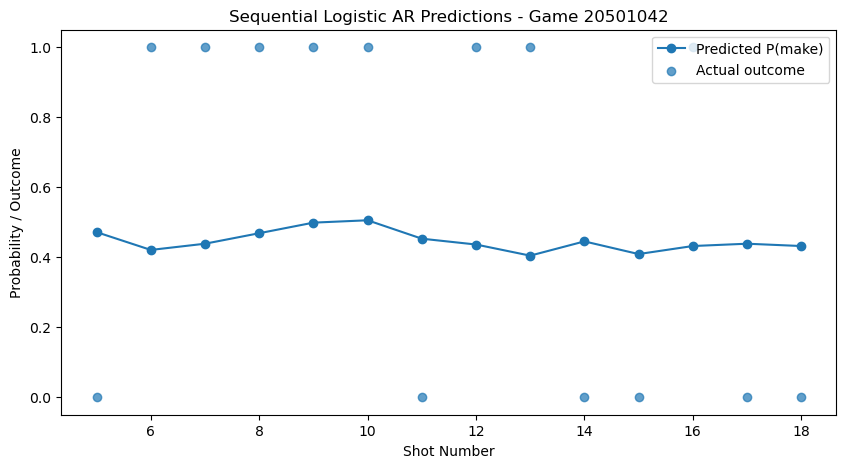

In [21]:
# plot for one game
example_game = seq_results["gameid"].iloc[0]
plot_df = seq_results[seq_results["gameid"] == example_game].copy()

plt.figure(figsize=(10, 5))
plt.plot(plot_df["shot_num"], plot_df["pred_prob"], marker="o", label="Predicted P(make)")
plt.scatter(plot_df["shot_num"], plot_df["actual"], alpha=0.7, label="Actual outcome")
plt.xlabel("Shot Number")
plt.ylabel("Probability / Outcome")
plt.title(f"Sequential Logistic AR Predictions - Game {example_game}")
plt.legend()
plt.show()

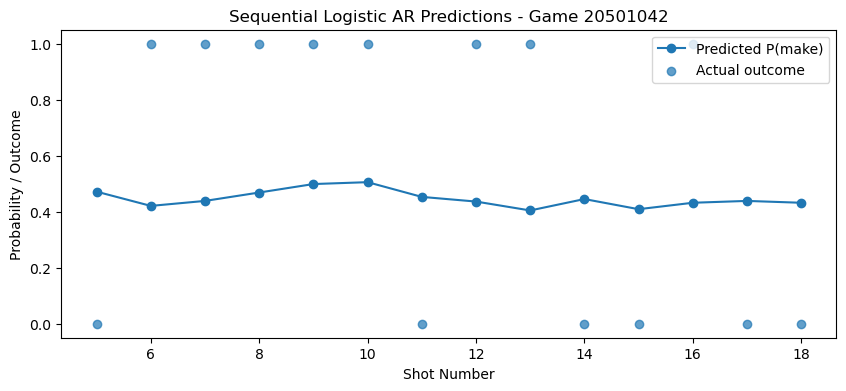

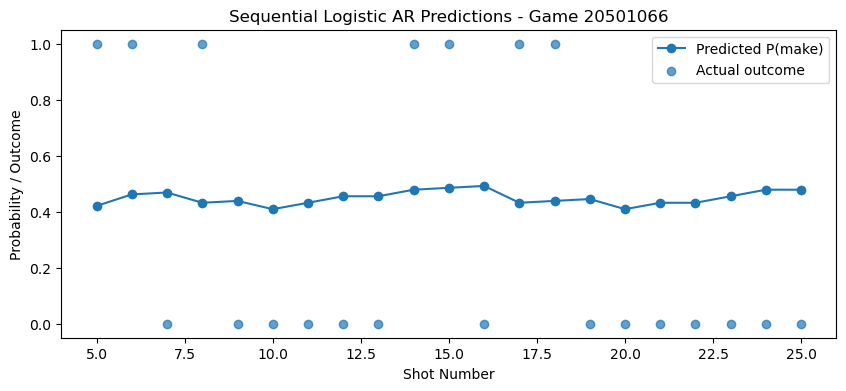

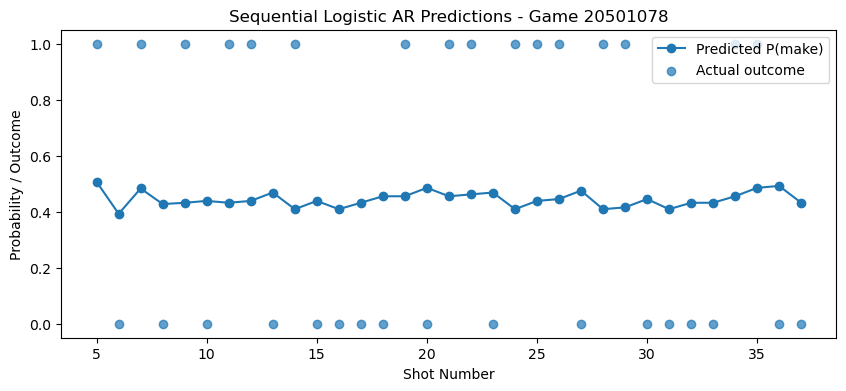

In [22]:
# a few games
example_games = seq_results["gameid"].drop_duplicates().head(3).tolist()

for game in example_games:
    plot_df = seq_results[seq_results["gameid"] == game].copy()

    plt.figure(figsize=(10, 4))
    plt.plot(plot_df["shot_num"], plot_df["pred_prob"], marker="o", label="Predicted P(make)")
    plt.scatter(plot_df["shot_num"], plot_df["actual"], alpha=0.7, label="Actual outcome")
    plt.xlabel("Shot Number")
    plt.ylabel("Probability / Outcome")
    plt.title(f"Sequential Logistic AR Predictions - Game {game}")
    plt.legend()
    plt.show()

In [23]:
# interpret coefficients
coef_names = ["intercept"] + feature_cols

coef_df = pd.DataFrame({
    "feature": coef_names,
    "weight": w.flatten()
})

coef_df

,feature,weight
0,intercept,-0.198420
1,lag_1,-0.237845
2,lag_2,0.205877
3,lag_3,-0.045719
4,hit_rate_5,-0.103911
5,make_streak,0.151197
